In [1]:
# ==========================================================
# Retail Sales Business Analysis
# ==========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# ==========================================================
# Upload Dataset
# ==========================================================

from google.colab import files

uploaded = files.upload()

Saving SuperStore Sales Interactive Dashboard.xlsx to SuperStore Sales Interactive Dashboard.xlsx


In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

df = pd.read_excel(
    "SuperStore Sales Interactive Dashboard.xlsx",
    sheet_name="Data"
)

In [4]:
# ==========================================================
# Preview Dataset
# ==========================================================

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Subtraction
0,43,CA-2016-101343,2016-07-17,2016-07-22,Standard Class,RA-19885,Ruben Ausman,Corporate,United States,Los Angeles,...,OFF-ST-10003479,Office Supplies,Storage,"Eldon Base for stackable storage shelf, platinum",77.88,2,0.0,3.8940,2016,5
1,514,CA-2017-163405,2017-12-21,2017-12-25,Standard Class,BN-11515,Bradley Nguyen,Consumer,United States,Los Angeles,...,OFF-AR-10003811,Office Supplies,Art,Newell 327,6.63,3,0.0,1.7901,2017,4
2,515,CA-2017-163405,2017-12-21,2017-12-25,Standard Class,BN-11515,Bradley Nguyen,Consumer,United States,Los Angeles,...,OFF-AR-10001246,Office Supplies,Art,Newell 317,5.88,2,0.0,1.7052,2017,4
3,1606,US-2016-115819,2016-04-19,2016-04-24,Second Class,JO-15280,Jas O'Carroll,Consumer,United States,Los Angeles,...,OFF-AR-10000823,Office Supplies,Art,Newell 307,5.46,3,0.0,1.5288,2016,5
4,1607,US-2016-115819,2016-04-19,2016-04-24,Second Class,JO-15280,Jas O'Carroll,Consumer,United States,Los Angeles,...,OFF-AR-10004456,Office Supplies,Art,Panasonic KP-4ABK Battery-Operated Pencil Shar...,73.20,5,0.0,21.2280,2016,5


In [5]:
# ==========================================================
# Dataset Overview
# ==========================================================

print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

df.info()

Rows    : 9994
Columns : 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object       

In [6]:
# ==========================================================
# Missing Values
# ==========================================================

df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
# ==========================================================
# Duplicate Records
# ==========================================================

print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
# ==========================================================
# Statistical Summary
# ==========================================================

df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Year,Subtraction
count,9994.000000,9994,9994,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,2016-04-30 00:07:12.259355392,2016-05-03 23:06:58.571142656,55190.379428,229.858001,3.789574,0.156203,28.656896,2015.722233,3.958175
min,1.000000,2014-01-03 00:00:00,2014-01-07 00:00:00,1040.000000,0.444000,1.000000,0.000000,-6599.978000,2014.000000,0.000000
25%,2499.250000,2015-05-23 00:00:00,2015-05-27 00:00:00,23223.000000,17.280000,2.000000,0.000000,1.728750,2015.000000,3.000000
50%,4997.500000,2016-06-26 00:00:00,2016-06-29 00:00:00,56430.500000,54.490000,3.000000,0.200000,8.666500,2016.000000,4.000000
75%,7495.750000,2017-05-14 00:00:00,2017-05-18 00:00:00,90008.000000,209.940000,5.000000,0.200000,29.364000,2017.000000,5.000000
max,9994.000000,2017-12-30 00:00:00,2018-01-05 00:00:00,99301.000000,22638.480000,14.000000,0.800000,8399.976000,2017.000000,7.000000
std,2885.163629,NaN,NaN,32063.693350,623.245101,2.225110,0.206452,234.260108,1.123555,1.747567


In [9]:
# ==========================================================
# Remove Unnecessary Columns
# ==========================================================

df = df.drop(columns=["Subtraction"])

In [10]:
# ==========================================================
# Convert Date Columns
# ==========================================================

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [11]:
# ==========================================================
# Verify Data Types
# ==========================================================

df.dtypes

,0
Row ID,int64
Order ID,object
Order Date,datetime64[ns]
Ship Date,datetime64[ns]
Ship Mode,object
Customer ID,object
Customer Name,object
Segment,object
Country,object
City,object


In [12]:
# ==========================================================
# Final Dataset Shape
# ==========================================================

print(df.shape)

(9994, 22)


In [13]:
# ==========================================================
# Business KPIs
# ==========================================================

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print(f"Total Sales      : ${total_sales:,.2f}")
print(f"Total Profit     : ${total_profit:,.2f}")
print(f"Total Orders     : {total_orders:,}")
print(f"Total Customers  : {total_customers:,}")

Total Sales      : $2,297,200.86
Total Profit     : $286,397.02
Total Orders     : 5,009
Total Customers  : 793


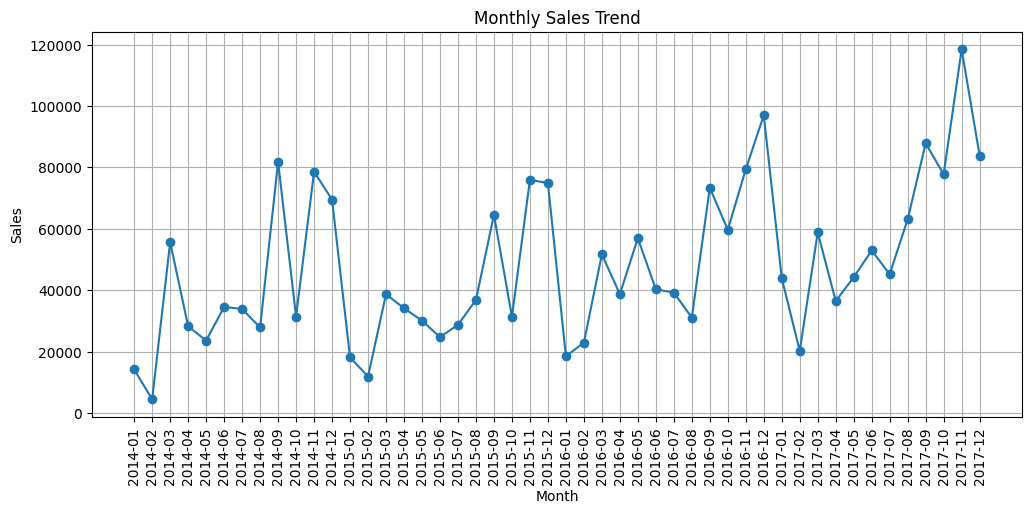

In [14]:
# ==========================================================
# Monthly Sales Trend
# ==========================================================

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

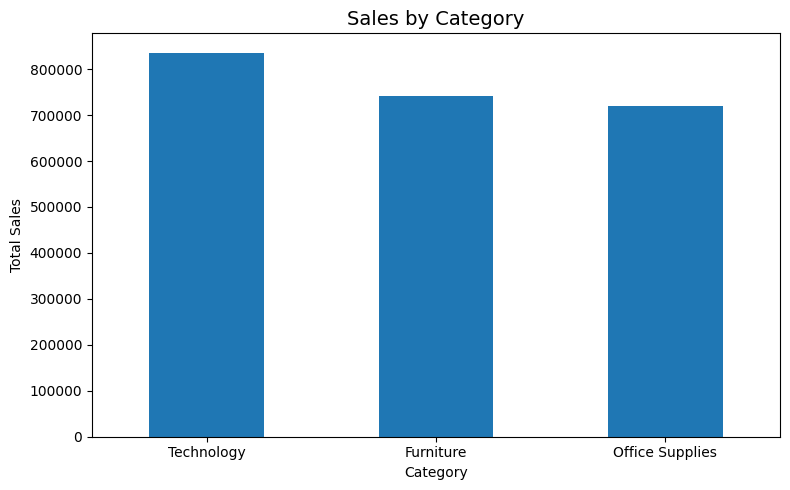

In [15]:
# ==========================================================
# Sales by Category
# ==========================================================

category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_sales.plot(kind="bar")

plt.title("Sales by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

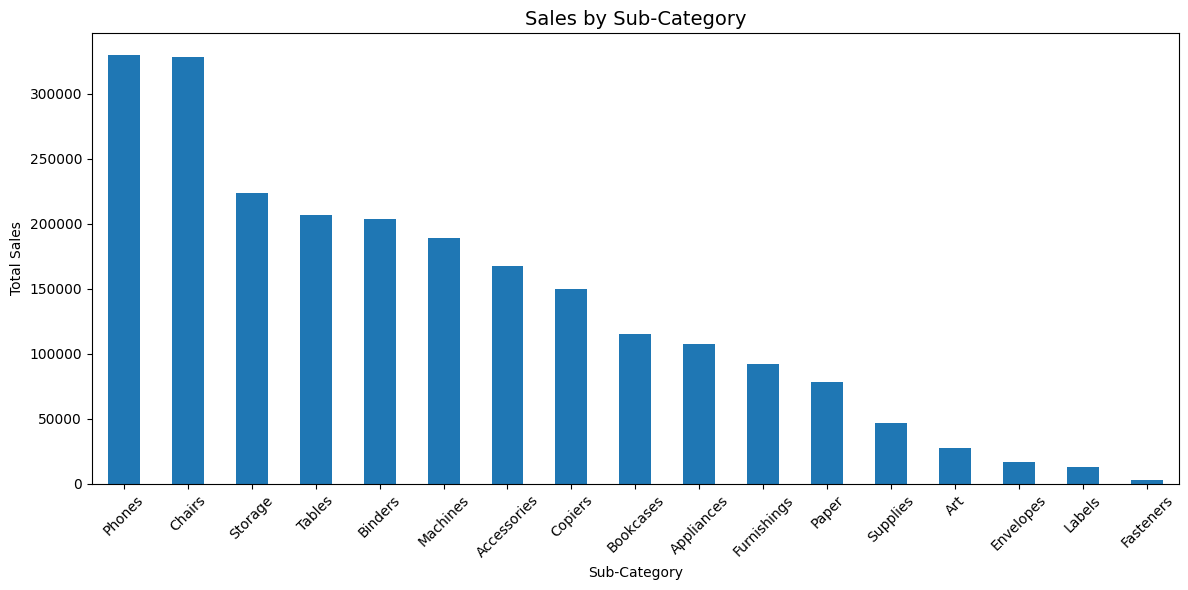

In [16]:
# ==========================================================
# Sales by Sub-Category
# ==========================================================

subcategory_sales = (
    df.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
subcategory_sales.plot(kind="bar")

plt.title("Sales by Sub-Category", fontsize=14)
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

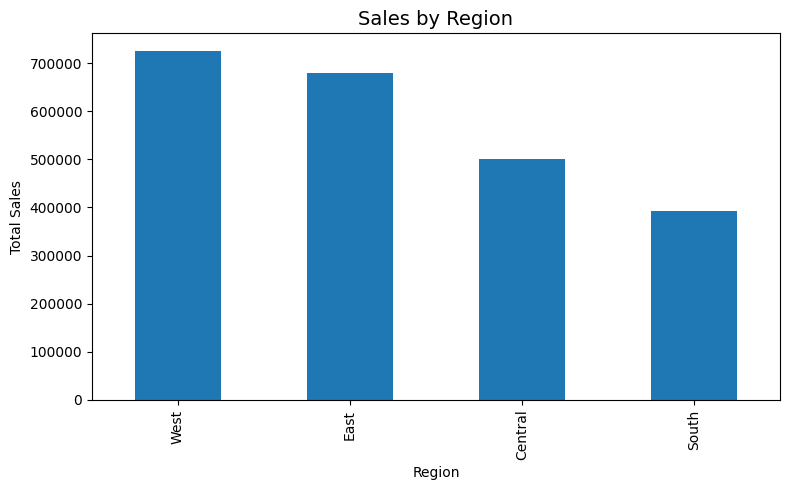

In [17]:
# ==========================================================
# Sales by Region
# ==========================================================

region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
region_sales.plot(kind="bar")

plt.title("Sales by Region", fontsize=14)
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

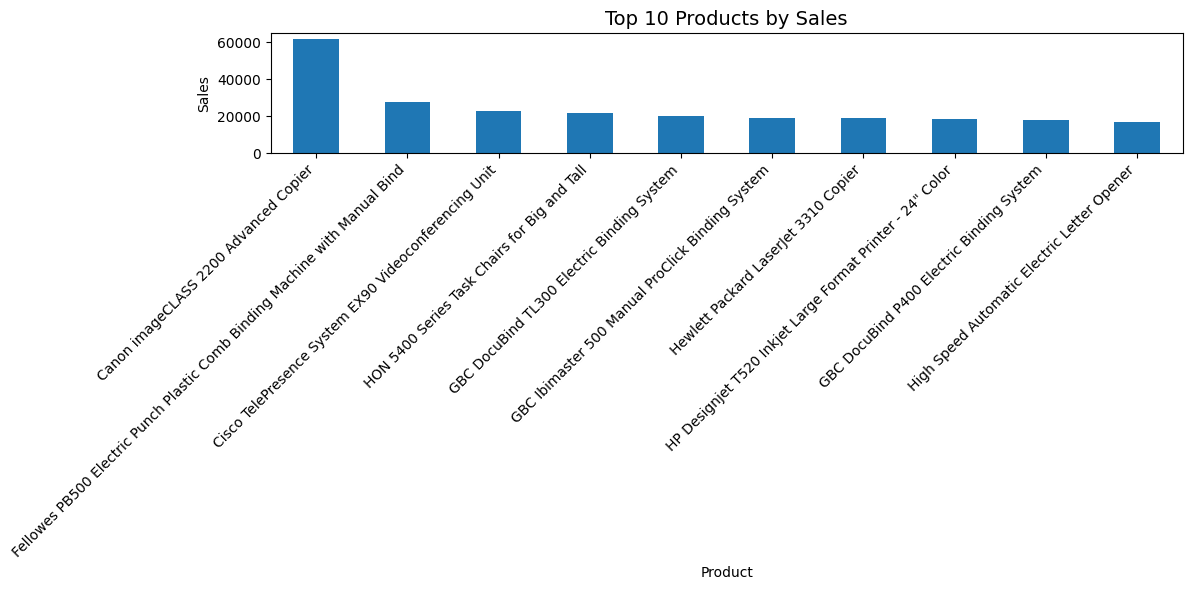

In [18]:
# ==========================================================
# Top 10 Products by Sales
# ==========================================================

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_products.plot(kind="bar")

plt.title("Top 10 Products by Sales", fontsize=14)
plt.xlabel("Product")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

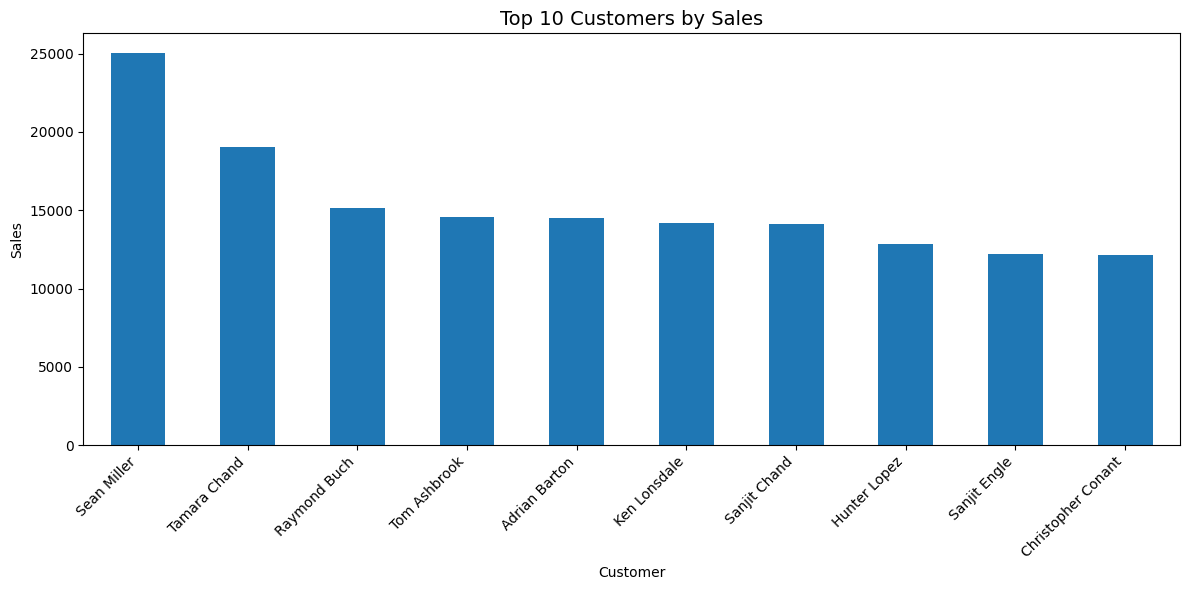

In [19]:
# ==========================================================
# Top 10 Customers by Sales
# ==========================================================

top_customers = (
    df.groupby("Customer Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))
top_customers.plot(kind="bar")

plt.title("Top 10 Customers by Sales", fontsize=14)
plt.xlabel("Customer")
plt.ylabel("Sales")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

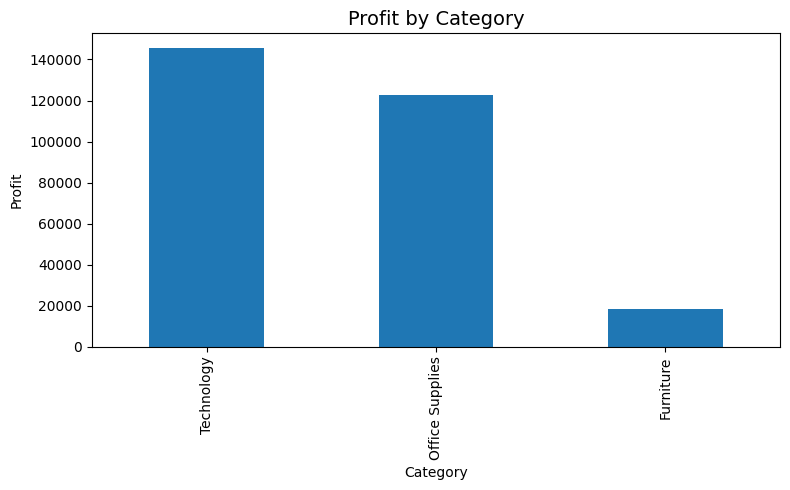

In [20]:
# ==========================================================
# Profit by Category
# ==========================================================

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
category_profit.plot(kind="bar")

plt.title("Profit by Category", fontsize=14)
plt.xlabel("Category")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

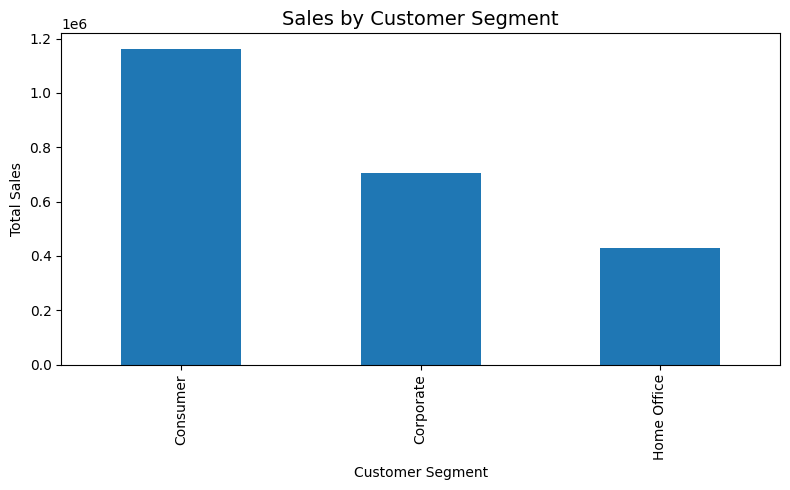

In [21]:
# ==========================================================
# Sales by Customer Segment
# ==========================================================

segment_sales = (
    df.groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
segment_sales.plot(kind="bar")

plt.title("Sales by Customer Segment", fontsize=14)
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

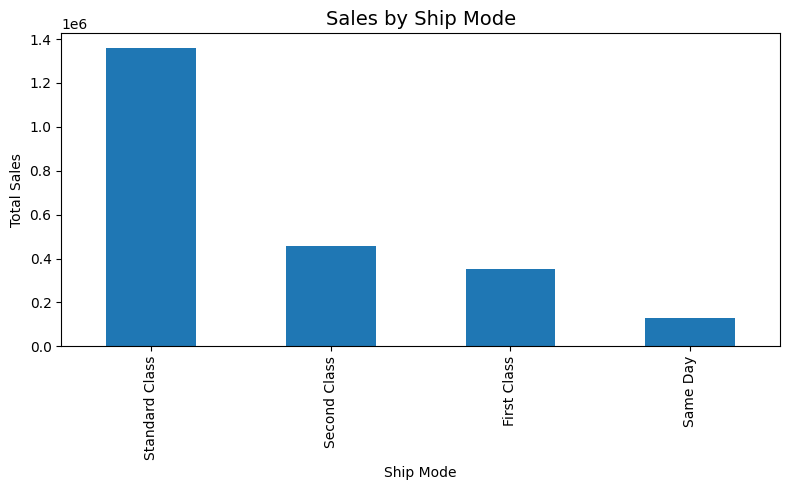

In [22]:
# ==========================================================
# Sales by Ship Mode
# ==========================================================

ship_sales = (
    df.groupby("Ship Mode")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))
ship_sales.plot(kind="bar")

plt.title("Sales by Ship Mode", fontsize=14)
plt.xlabel("Ship Mode")
plt.ylabel("Total Sales")

plt.tight_layout()
plt.show()

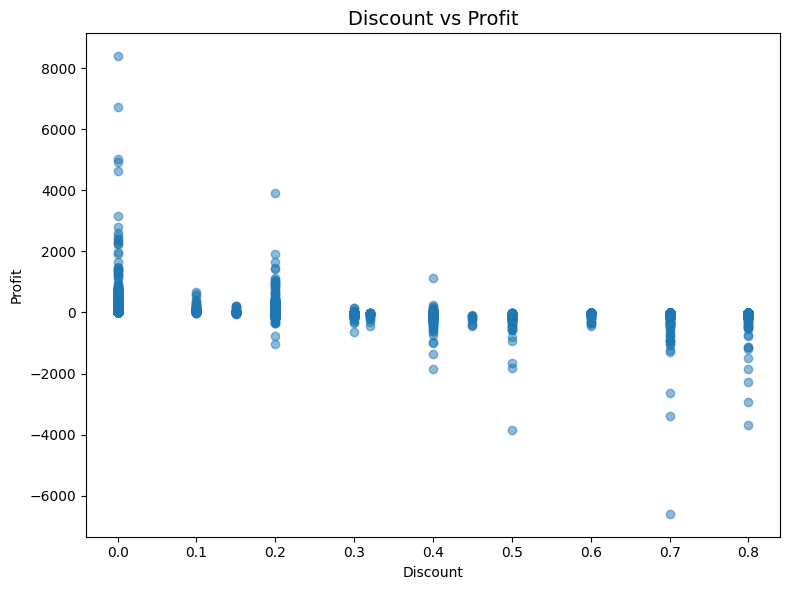

In [23]:
# ==========================================================
# Discount vs Profit
# ==========================================================

plt.figure(figsize=(8,6))

plt.scatter(
    df["Discount"],
    df["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit", fontsize=14)
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

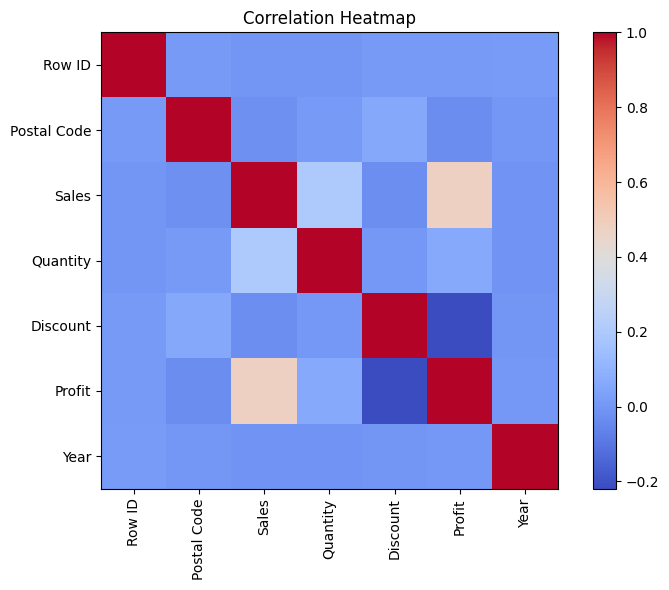

In [24]:
# ==========================================================
# Correlation Heatmap
# ==========================================================

plt.figure(figsize=(8,6))

numeric_df = df.select_dtypes(include=["number"])

plt.imshow(numeric_df.corr(), cmap="coolwarm")

plt.colorbar()

plt.xticks(
    range(len(numeric_df.columns)),
    numeric_df.columns,
    rotation=90
)

plt.yticks(
    range(len(numeric_df.columns)),
    numeric_df.columns
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

In [25]:
# ==========================================================
# Business Insights
# ==========================================================

print("1. Sales show a clear upward trend from 2014 to 2017.")
print("2. Q4 consistently records the highest sales, indicating strong seasonal demand.")
print("3. Technology and Office Supplies contribute significantly to overall revenue.")
print("4. A small number of products generate a large share of total sales.")
print("5. A few high-value customers contribute disproportionately to revenue.")
print("6. Higher discounts are often associated with lower or negative profits.")
print("7. Sales performance varies across regions, highlighting opportunities for regional strategies.")
print("8. Standard Class shipping accounts for the majority of sales.")
print("9. Consumer and Corporate segments contribute most of the revenue.")
print("10. Profitability depends not only on sales volume but also on discount strategy.")

1. Sales show a clear upward trend from 2014 to 2017.
2. Q4 consistently records the highest sales, indicating strong seasonal demand.
3. Technology and Office Supplies contribute significantly to overall revenue.
4. A small number of products generate a large share of total sales.
5. A few high-value customers contribute disproportionately to revenue.
6. Higher discounts are often associated with lower or negative profits.
7. Sales performance varies across regions, highlighting opportunities for regional strategies.
8. Standard Class shipping accounts for the majority of sales.
9. Consumer and Corporate segments contribute most of the revenue.
10. Profitability depends not only on sales volume but also on discount strategy.


In [26]:
# ==========================================================
# Executive Summary
# ==========================================================

print("""
Executive Summary

• Total sales increased steadily over the four-year period.
• Sales peaked during year-end months, showing strong seasonality.
• Technology products generated the highest business value.
• A limited number of customers and products drive a significant share of revenue.
• Excessive discounting negatively impacts profitability.
• Regional performance differences indicate expansion opportunities.
• Optimizing discount policies and focusing on high-performing customers can improve profits.
""")


Executive Summary

• Total sales increased steadily over the four-year period.
• Sales peaked during year-end months, showing strong seasonality.
• Technology products generated the highest business value.
• A limited number of customers and products drive a significant share of revenue.
• Excessive discounting negatively impacts profitability.
• Regional performance differences indicate expansion opportunities.
• Optimizing discount policies and focusing on high-performing customers can improve profits.



In [28]:
# ==========================================================
# SQL Business Analysis (Business Questions)
# ==========================================================

In [29]:
# ==========================================================
# SQL Business Analysis (Business Questions)
# ==========================================================

In [30]:
SELECT
    SUM(Sales) AS Total_Sales,
    SUM(Profit) AS Total_Profit,
    COUNT(DISTINCT Order_ID) AS Total_Orders
FROM RetailSales;

IndentationError: unexpected indent (198457399.py, line 2)